Rows, Columns: (1460, 81)

Sample rows:
   GrLivArea  TotRmsAbvGrd  SalePrice
0       1710             8     208500
1       1262             6     181500
2       1786             6     223500
3       1717             7     140000
4       2198             9     250000

Train shape: (1168, 1) Test shape: (292, 1)

Learned model: SalePrice = 102.49 * GrLivArea + 24899.75

Mean Squared Error (MSE): 3418946311.18
R^2 Score: 0.5543



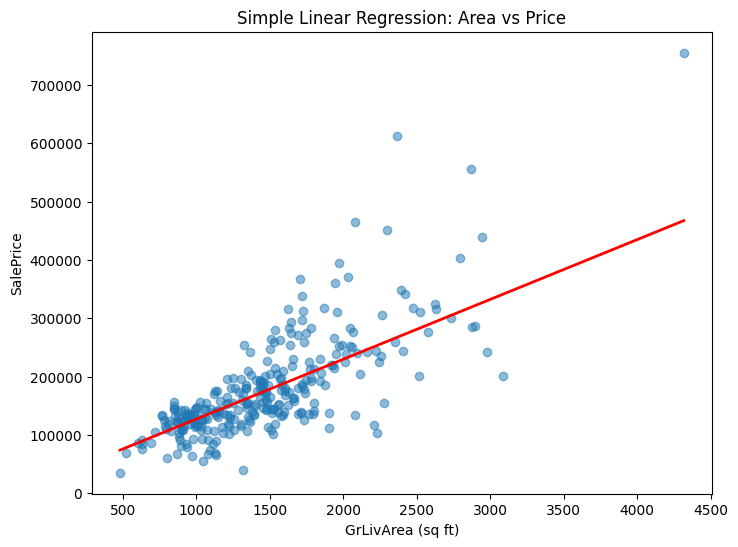

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# -------------------------------------------------------
# 1. Load dataset
# -------------------------------------------------------
df = pd.read_csv("train.csv")
print(f"Rows, Columns: {df.shape}\n")

# -------------------------------------------------------
# 2. Select only required columns for display + model
# -------------------------------------------------------
cols = ['GrLivArea', 'TotRmsAbvGrd', 'SalePrice']
df_small = df[cols].dropna()

# Sample rows output
print("Sample rows:")
print(df_small.head().to_string(index=True))
print()

# -------------------------------------------------------
# 3. Simple Linear Regression (GrLivArea → SalePrice)
# -------------------------------------------------------
X = df_small[['GrLivArea']]
y = df_small['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train shape: {X_train.shape} Test shape: {X_test.shape}\n")

model = LinearRegression()
model.fit(X_train, y_train)

coef = model.coef_[0]
intercept = model.intercept_

print(f"Learned model: SalePrice = {coef:.2f} * GrLivArea + {intercept:.2f}\n")

# -------------------------------------------------------
# 4. Predictions + Evaluation
# -------------------------------------------------------
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R^2 Score: {r2:.4f}\n")

# -------------------------------------------------------
# 5. Red Regression Line Plot
# -------------------------------------------------------
sort_idx = np.argsort(X_test['GrLivArea'].values)
X_test_sorted = X_test['GrLivArea'].values[sort_idx]
y_pred_sorted = y_pred[sort_idx]

plt.figure(figsize=(8, 6))
plt.scatter(X_test['GrLivArea'], y_test, alpha=0.5)
plt.plot(X_test_sorted, y_pred_sorted, color='red', linewidth=2)
plt.xlabel("GrLivArea (sq ft)")
plt.ylabel("SalePrice")
plt.title("Simple Linear Regression: Area vs Price")
plt.show()
